# Intervention Analysis

This notebook analyzes the fact checking intervention experiments for the misinformation-spread project.

It compares three intervention strategies across three network topologies:

- **Random** fact checking nodes
- **High degree** fact checking nodes
- **High betweenness** fact checking nodes

Important note: Some interventions may prevent misinformation from ever reaching 50% of the network. In those cases, `t50` is missing (`NaN`). This is not a mistake; it means the intervention was strong enough that the outbreak did not reach the 50% threshold. Because of this, the notebook uses **AUC**, **final outbreak size**, and **fraction of trials reaching 50% infection** as the main intervention metrics.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

# Display settings
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

In [2]:
results_path = DATA_DIR / "intervention_results.csv"
results = pd.read_csv(results_path)

print("Rows:", len(results))
print("Columns:", list(results.columns))
results.head()

Rows: 3000
Columns: ['topology', 'strategy', 'fraction', 'trial', 'n', 'beta', 'gamma', 't10', 't50', 'peak_infected', 'auc', 'final_size', 'duration']


,topology,strategy,fraction,trial,n,beta,gamma,t10,t50,peak_infected,auc,final_size,duration
0,ER,none,0.0,0,1000,0.15,0.05,6,10.0,706,19207.5,0.986,153
1,ER,none,0.0,1,1000,0.15,0.05,5,9.0,725,20140.5,0.987,167
2,ER,none,0.0,2,1000,0.15,0.05,5,9.0,746,20514.5,0.994,140
3,ER,none,0.0,3,1000,0.15,0.05,7,11.0,711,19102.5,0.991,136
4,ER,none,0.0,4,1000,0.15,0.05,6,10.0,720,19185.5,0.991,162


We check whether any columns contain missing values. Missing `t50` values are expected when misinformation never reaches 50% infection.

In [3]:
results.isna().sum()

topology           0
strategy           0
fraction           0
trial              0
n                  0
beta               0
gamma              0
t10                0
t50              434
peak_infected      0
auc                0
final_size         0
duration           0
dtype: int64

In [4]:
# Fraction of trials where t50 is missing for each condition
missing_t50_table = (
    results
    .groupby(["topology", "strategy", "fraction"])["t50"]
    .apply(lambda x: x.isna().mean())
    .reset_index(name="missing_t50_fraction")
)

missing_t50_table

,topology,strategy,fraction,missing_t50_fraction
0,BA,betweenness,0.01,0.00
1,BA,betweenness,0.05,0.07
2,BA,betweenness,0.10,1.00
3,BA,degree,0.01,0.00
4,BA,degree,0.05,0.08
5,BA,degree,0.10,1.00
6,BA,none,0.00,0.00
7,BA,random,0.01,0.00
8,BA,random,0.05,0.00
9,BA,random,0.10,0.00


`t50` measures the time needed to reach 50% active infection. However, if a trial never reaches that threshold, `t50` is missing. To capture this directly, we create a new Boolean metric:

- `reached_50 = True` if the trial reached 50% infection
- `reached_50 = False` if it never reached 50% infection

For intervention experiments, a lower `reached_50` rate means the intervention is more effective.

In [5]:
results["reached_50"] = results["t50"].notna()

reached_table = (
    results
    .groupby(["topology", "strategy", "fraction"])["reached_50"]
    .mean()
    .reset_index()
)

reached_table

,topology,strategy,fraction,reached_50
0,BA,betweenness,0.01,1.00
1,BA,betweenness,0.05,0.93
2,BA,betweenness,0.10,0.00
3,BA,degree,0.01,1.00
4,BA,degree,0.05,0.92
5,BA,degree,0.10,0.00
6,BA,none,0.00,1.00
7,BA,random,0.01,1.00
8,BA,random,0.05,1.00
9,BA,random,0.10,1.00


Interpretation:

- Higher `t50` = slower misinformation spread, but only among trials that reached 50% infection
- Lower `final_size` = fewer total nodes ever infected
- Lower `auc` = lower total misinformation burden over time
- Lower `reached_50` = fewer outbreaks reached 50% infection

In [6]:
summary = (
    results
    .groupby(["topology", "strategy", "fraction"])[["t50", "peak_infected", "final_size", "auc", "reached_50"]]
    .agg(["mean", "std"])
)

summary

t50           peak_infected             \
                                    mean       std          mean        std   
topology strategy    fraction                                                 
BA       betweenness 0.01      10.910000  1.272038        677.72  17.091010   
                     0.05      19.612903  2.591928        537.45  21.350076   
                     0.10            NaN       NaN        387.78  25.799765   
         degree      0.01      10.820000  1.217548        679.21  16.720697   
                     0.05      19.706522  2.078345        531.02  21.303473   
                     0.10            NaN       NaN        369.49  27.939869   
         none        0.00       7.900000  1.000000        738.21  15.577305   
         random      0.01       8.000000  1.005038        726.82  14.642114   
                     0.05       8.480000  1.058682        685.50  18.443197   
                     0.10       8.960000  0.941952        636.15  16.405453   
ER       betweenness 0.01      10.850000  1.048086        713.67  16.439700   
                     0.05      12.490000  1.218502        655.82  16.019798   
                     0.10      15.280000  1.436044        588.14  17.019312   
         degree      0.01      10.830000  0.932630        713.23  17.421022   
                     0.05      12.570000  1.066051        655.42  16.603018   
                     0.10      15.420000  1.342243        587.20  16.238127   
         none        0.00      10.410000  0.888706        728.26  15.224661   
         random      0.01      10.390000  0.886430        719.97  18.237743   
                     0.05      10.990000  0.948098        679.26  15.212714   
                     0.10      12.020000  1.136893        629.87  13.888194   
WS       betweenness 0.01      19.000000  1.595448        618.77  20.950570   
                     0.05      23.423913  2.409841        542.45  25.823556   
                     0.10      25.250000  2.217356        453.70  29.871611   
         degree      0.01      18.900000  1.941050        620.17  24.618731   
                     0.05      22.625000  2.318121        546.48  24.042673   
                     0.10      27.400000  2.509980        446.26  27.908805   
         none        0.00      17.760000  1.511705        639.02  21.357931   
         random      0.01      17.850000  1.684001        630.05  19.493265   
                     0.05      19.880000  1.659256        589.57  21.477381   
                     0.10      22.285714  2.417663        528.39  26.246653   

                              final_size                 auc              \
                                    mean       std      mean         std   
topology strategy    fraction                                              
BA       betweenness 0.01        0.97416  0.004505  19404.45  640.014763   
                     0.05        0.89182  0.009713  17798.83  724.906808   
                     0.10        0.77102  0.018141  15485.26  709.155695   
         degree      0.01        0.97450  0.004416  19413.86  649.113670   
                     0.05        0.88738  0.010834  17657.20  738.406536   
                     0.10        0.75730  0.018853  15190.88  787.032013   
         none        0.00        0.99501  0.002699  19825.07  676.544970   
         random      0.01        0.98451  0.002376  19610.31  666.467162   
                     0.05        0.94166  0.003983  18787.33  549.044883   
                     0.10        0.88809  0.004248  17729.71  569.368413   
ER       betweenness 0.01        0.97906  0.003296  19614.06  620.398004   
                     0.05        0.93484  0.004412  18728.96  518.576576   
                     0.10        0.87646  0.005102  17552.30  600.904487   
         degree      0.01        0.97922  0.003404  19593.02  577.706813   
                     0.05        0.93495  0.003976  18727.03  502.087369   
                     0.10        0.87688  0.004981  17576.63 

We first compare strategies at 5% coverage, which is a useful middle intervention level.

In [7]:
fraction_5 = results[results["fraction"] == 0.05].copy()
fraction_5.head()

,topology,strategy,fraction,trial,n,beta,gamma,t10,t50,peak_infected,auc,final_size,duration,reached_50
200,ER,random,0.05,0,1000,0.15,0.05,6,10.0,674,18231.5,0.936,222,True
201,ER,random,0.05,1,1000,0.15,0.05,8,12.0,695,19766.5,0.938,178,True
202,ER,random,0.05,2,1000,0.15,0.05,7,12.0,677,19243.5,0.935,198,True
203,ER,random,0.05,3,1000,0.15,0.05,5,10.0,652,18546.5,0.941,123,True
204,ER,random,0.05,4,1000,0.15,0.05,6,10.0,668,18672.5,0.941,138,True


### Figure 1: Time to 50% infection at 5% coverage

Higher values mean slower spread. Missing `t50` values are ignored by the mean, so this plot should be interpreted together with the reached-50% plot below.

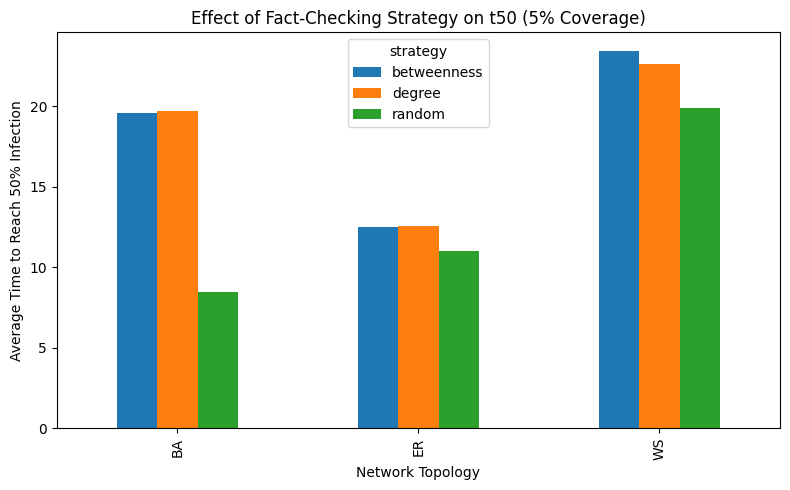

strategy,betweenness,degree,random
topology,,,
BA,19.612903,19.706522,8.48
ER,12.490000,12.570000,10.99
WS,23.423913,22.625000,19.88


In [8]:
plot_data = (
    fraction_5
    .groupby(["topology", "strategy"])["t50"]
    .mean()
    .unstack()
)

ax = plot_data.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Average Time to Reach 50% Infection")
ax.set_xlabel("Network Topology")
ax.set_title("Effect of Fact-Checking Strategy on t50 (5% Coverage)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intervention_t50_5percent.png", dpi=300)
plt.show()

plot_data

### Figure 2: Fraction of trials reaching 50% infection at 5% coverage

Lower values mean better intervention performance.

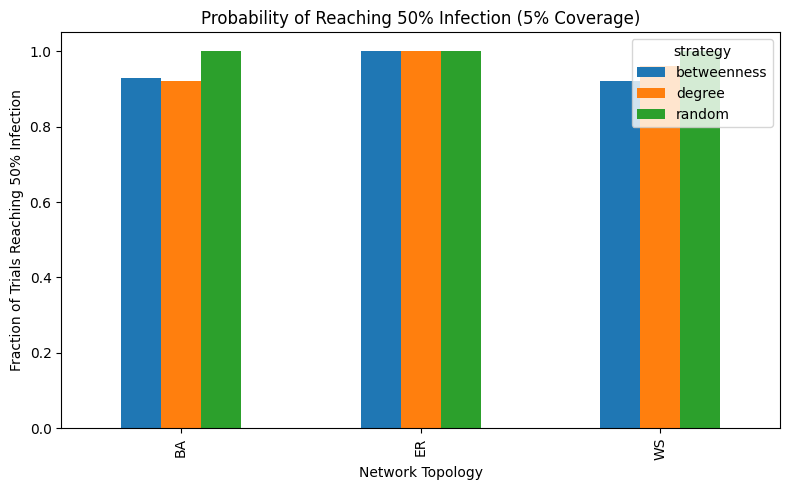

strategy,betweenness,degree,random
topology,,,
BA,0.93,0.92,1.0
ER,1.00,1.00,1.0
WS,0.92,0.96,1.0


In [9]:
plot_data = (
    fraction_5
    .groupby(["topology", "strategy"])["reached_50"]
    .mean()
    .unstack()
)

ax = plot_data.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Fraction of Trials Reaching 50% Infection")
ax.set_xlabel("Network Topology")
ax.set_title("Probability of Reaching 50% Infection (5% Coverage)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intervention_reached50_5percent.png", dpi=300)
plt.show()

plot_data

### Figure 3: Final outbreak size at 5% coverage

Lower values mean fewer total nodes were ever infected.

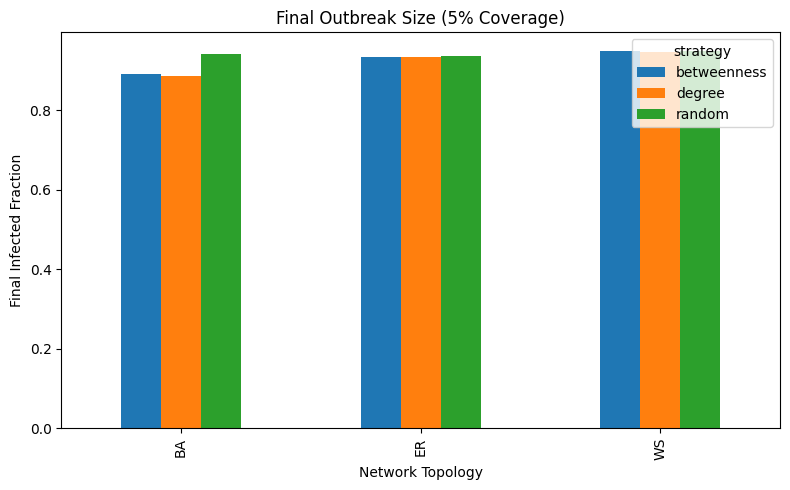

strategy,betweenness,degree,random
topology,,,
BA,0.89182,0.88738,0.94166
ER,0.93484,0.93495,0.93826
WS,0.94882,0.94689,0.94928


In [10]:
plot_data = (
    fraction_5
    .groupby(["topology", "strategy"])["final_size"]
    .mean()
    .unstack()
)

ax = plot_data.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Final Infected Fraction")
ax.set_xlabel("Network Topology")
ax.set_title("Final Outbreak Size (5% Coverage)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intervention_final_size_5percent.png", dpi=300)
plt.show()

plot_data

### Figure 4: Total misinformation burden at 5% coverage

AUC is the area under the active-infection curve. Lower AUC means lower total misinformation burden over time.

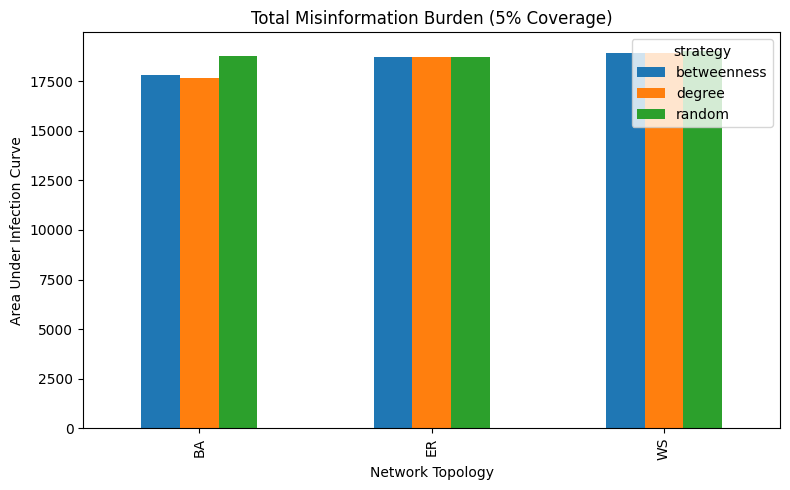

strategy,betweenness,degree,random
topology,,,
BA,17798.83,17657.20,18787.33
ER,18728.96,18727.03,18729.17
WS,18948.30,18936.43,19019.43


In [11]:
plot_data = (
    fraction_5
    .groupby(["topology", "strategy"])["auc"]
    .mean()
    .unstack()
)

ax = plot_data.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Area Under Infection Curve")
ax.set_xlabel("Network Topology")
ax.set_title("Total Misinformation Burden (5% Coverage)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "intervention_auc_5percent.png", dpi=300)
plt.show()

plot_data

These plots show how intervention performance changes as fact-checking coverage increases from 1% to 5% to 10%.

Because `none` only exists at fraction 0, we remove it from these coverage plots.

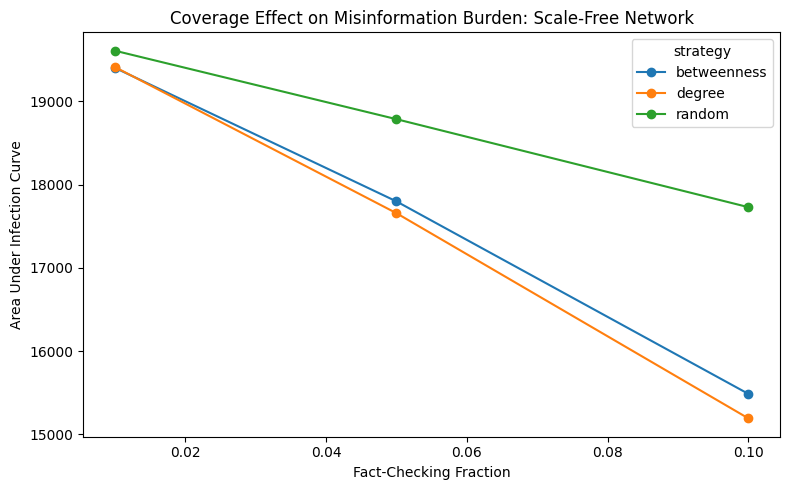

strategy,betweenness,degree,random
fraction,,,
0.01,19404.45,19413.86,19610.31
0.05,17798.83,17657.20,18787.33
0.10,15485.26,15190.88,17729.71


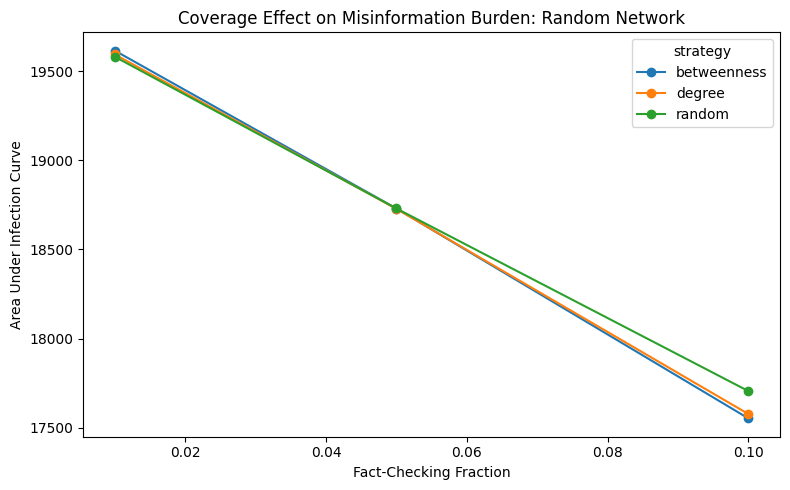

strategy,betweenness,degree,random
fraction,,,
0.01,19614.06,19593.02,19579.84
0.05,18728.96,18727.03,18729.17
0.10,17552.30,17576.63,17705.33


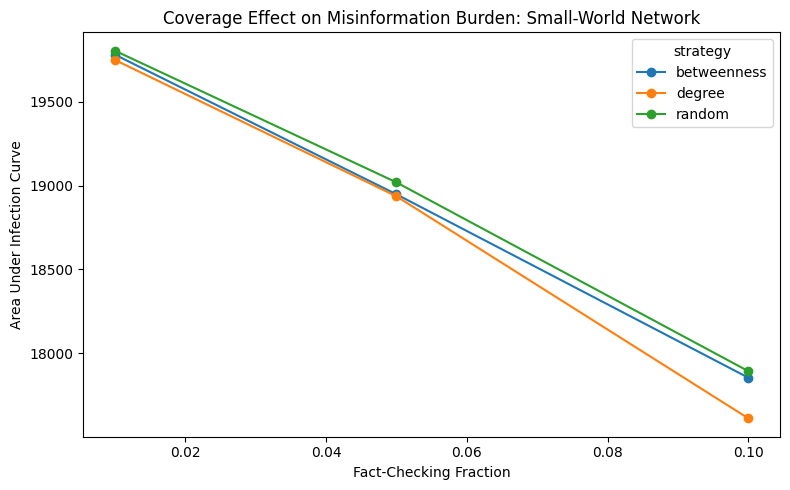

strategy,betweenness,degree,random
fraction,,,
0.01,19781.48,19750.15,19805.14
0.05,18948.30,18936.43,19019.43
0.10,17854.01,17611.50,17893.03


In [12]:
intervention_only = results[results["strategy"] != "none"].copy()

for topology, title in {
    "BA": "Scale-Free Network",
    "ER": "Random Network",
    "WS": "Small-World Network"
}.items():
    subset = intervention_only[intervention_only["topology"] == topology]
    
    plot_data = (
        subset
        .groupby(["fraction", "strategy"])["auc"]
        .mean()
        .unstack()
    )
    
    ax = plot_data.plot(marker="o", figsize=(8, 5))
    ax.set_xlabel("Fact-Checking Fraction")
    ax.set_ylabel("Area Under Infection Curve")
    ax.set_title(f"Coverage Effect on Misinformation Burden: {title}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{topology}_coverage_effect_auc.png", dpi=300)
    plt.show()
    
    display(plot_data)

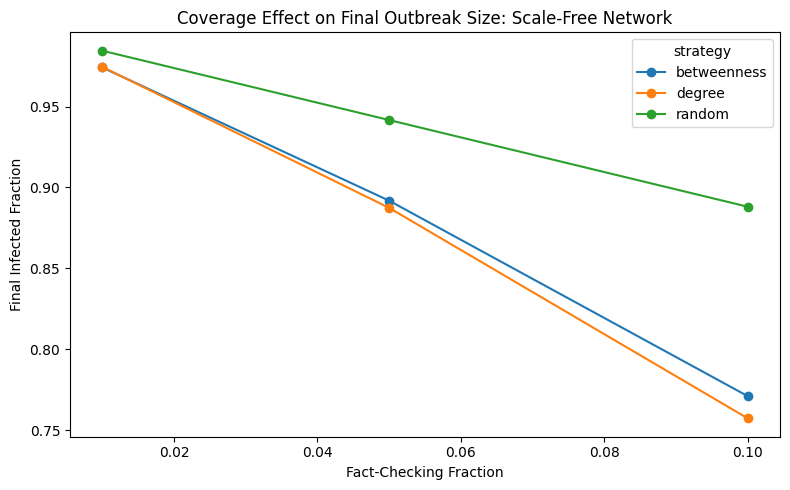

strategy,betweenness,degree,random
fraction,,,
0.01,0.97416,0.97450,0.98451
0.05,0.89182,0.88738,0.94166
0.10,0.77102,0.75730,0.88809


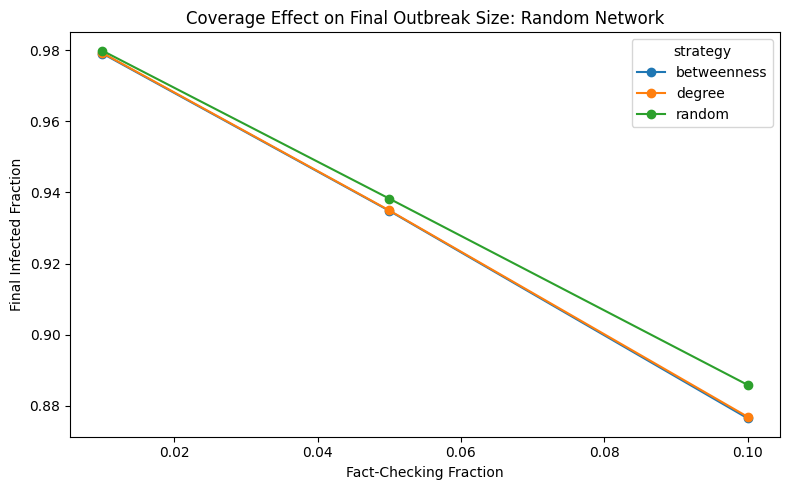

strategy,betweenness,degree,random
fraction,,,
0.01,0.97906,0.97922,0.97985
0.05,0.93484,0.93495,0.93826
0.10,0.87646,0.87688,0.88585


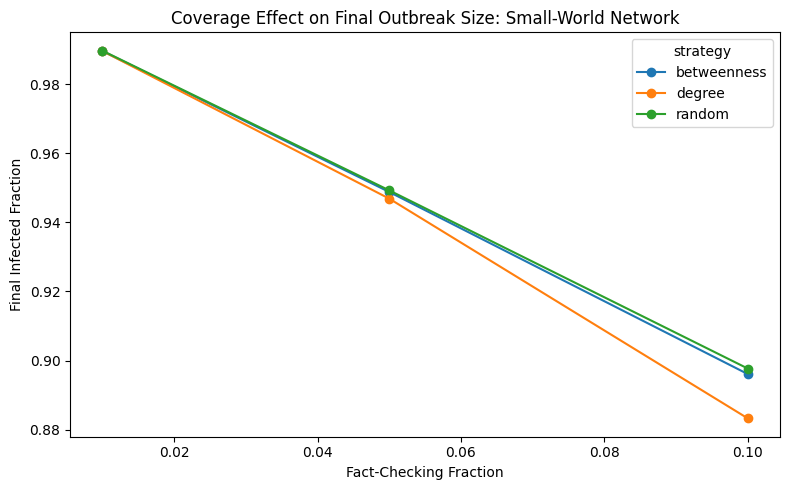

strategy,betweenness,degree,random
fraction,,,
0.01,0.98963,0.98964,0.98973
0.05,0.94882,0.94689,0.94928
0.10,0.89608,0.88325,0.89768


In [13]:
for topology, title in {
    "BA": "Scale-Free Network",
    "ER": "Random Network",
    "WS": "Small-World Network"
}.items():
    subset = intervention_only[intervention_only["topology"] == topology]
    
    plot_data = (
        subset
        .groupby(["fraction", "strategy"])["final_size"]
        .mean()
        .unstack()
    )
    
    ax = plot_data.plot(marker="o", figsize=(8, 5))
    ax.set_xlabel("Fact-Checking Fraction")
    ax.set_ylabel("Final Infected Fraction")
    ax.set_title(f"Coverage Effect on Final Outbreak Size: {title}")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{topology}_coverage_effect_final_size.png", dpi=300)
    plt.show()
    
    display(plot_data)

## Identify best strategies

For interventions:

- Best by `auc`: lowest mean AUC
- Best by `final_size`: lowest final infected fraction
- Best by `reached_50`: lowest fraction of trials reaching 50% infection
- Best by `t50`: highest t50 among trials that reached 50%, but this is less reliable when many trials never reach 50%

In [14]:
mean_metrics = (
    results
    .groupby(["topology", "strategy", "fraction"])[["t50", "final_size", "auc", "reached_50"]]
    .mean()
    .reset_index()
)

# Best by AUC for each topology and fraction
best_auc = (
    mean_metrics
    .sort_values(["topology", "fraction", "auc"], ascending=[True, True, True])
    .groupby(["topology", "fraction"])
    .head(1)
)

best_auc

,topology,strategy,fraction,t50,final_size,auc,reached_50
6,BA,none,0.00,7.900000,0.99501,19825.07,1.00
0,BA,betweenness,0.01,10.910000,0.97416,19404.45,1.00
4,BA,degree,0.05,19.706522,0.88738,17657.20,0.92
5,BA,degree,0.10,NaN,0.75730,15190.88,0.00
16,ER,none,0.00,10.410000,0.99041,19844.99,1.00
17,ER,random,0.01,10.390000,0.97985,19579.84,1.00
14,ER,degree,0.05,12.570000,0.93495,18727.03,1.00
12,ER,betweenness,0.10,15.280000,0.87646,17552.30,1.00
26,WS,none,0.00,17.760000,0.99961,19906.70,1.00
23,WS,degree,0.01,18.900000,0.98964,19750.15,1.00


In [15]:
# Best by final outbreak size for each topology and fraction
best_final_size = (
    mean_metrics
    .sort_values(["topology", "fraction", "final_size"], ascending=[True, True, True])
    .groupby(["topology", "fraction"])
    .head(1)
)

best_final_size

,topology,strategy,fraction,t50,final_size,auc,reached_50
6,BA,none,0.00,7.900000,0.99501,19825.07,1.00
0,BA,betweenness,0.01,10.910000,0.97416,19404.45,1.00
4,BA,degree,0.05,19.706522,0.88738,17657.20,0.92
5,BA,degree,0.10,NaN,0.75730,15190.88,0.00
16,ER,none,0.00,10.410000,0.99041,19844.99,1.00
10,ER,betweenness,0.01,10.850000,0.97906,19614.06,1.00
11,ER,betweenness,0.05,12.490000,0.93484,18728.96,1.00
12,ER,betweenness,0.10,15.280000,0.87646,17552.30,1.00
26,WS,none,0.00,17.760000,0.99961,19906.70,1.00
20,WS,betweenness,0.01,19.000000,0.98963,19781.48,1.00


In [16]:
# Best by preventing trials from reaching 50% infection
best_reached_50 = (
    mean_metrics
    .sort_values(["topology", "fraction", "reached_50"], ascending=[True, True, True])
    .groupby(["topology", "fraction"])
    .head(1)
)

best_reached_50

,topology,strategy,fraction,t50,final_size,auc,reached_50
6,BA,none,0.00,7.900000,0.99501,19825.07,1.00
0,BA,betweenness,0.01,10.910000,0.97416,19404.45,1.00
4,BA,degree,0.05,19.706522,0.88738,17657.20,0.92
2,BA,betweenness,0.10,NaN,0.77102,15485.26,0.00
16,ER,none,0.00,10.410000,0.99041,19844.99,1.00
10,ER,betweenness,0.01,10.850000,0.97906,19614.06,1.00
11,ER,betweenness,0.05,12.490000,0.93484,18728.96,1.00
12,ER,betweenness,0.10,15.280000,0.87646,17552.30,1.00
26,WS,none,0.00,17.760000,0.99961,19906.70,1.00
20,WS,betweenness,0.01,19.000000,0.98963,19781.48,1.00


## Statistical tests

### Baseline topology comparison

This ANOVA tests whether baseline spread speed differs across network topologies using the no intervention condition.

In [17]:
baseline = results[results["strategy"] == "none"].copy()

ba_t50 = baseline[baseline["topology"] == "BA"]["t50"].dropna()
er_t50 = baseline[baseline["topology"] == "ER"]["t50"].dropna()
ws_t50 = baseline[baseline["topology"] == "WS"]["t50"].dropna()

f_stat, p_value = f_oneway(ba_t50, er_t50, ws_t50)

print("Baseline topology ANOVA on t50")
print("F-statistic:", f_stat)
print("p-value:", p_value)

Baseline topology ANOVA on t50
F-statistic: 1933.00917135562
p-value: 5.274685185719931e-171


### Intervention strategy comparison within each topology

Because `t50` can be missing when an intervention prevents reaching 50% infection, we use AUC for intervention statistical tests. Lower AUC indicates lower misinformation burden.

In [18]:
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

repeated_rows = []

for topology in ["BA", "ER", "WS"]:
    subset = results[
        (results["topology"] == topology)
        & (results["fraction"] == 0.05)
        & (results["strategy"].isin(["random", "degree", "betweenness"]))
    ][["trial", "strategy", "auc"]].copy()

    repeated_fit = AnovaRM(
        data=subset,
        depvar="auc",
        subject="trial",
        within=["strategy"],
    ).fit()

    row = repeated_fit.anova_table.iloc[0]
    f_stat = row["F Value"]
    numerator_df = row["Num DF"]
    denominator_df = row["Den DF"]
    p_value = row["Pr > F"]

    partial_eta_squared = (
        f_stat * numerator_df
        / ((f_stat * numerator_df) + denominator_df)
    )

    repeated_rows.append({
        "Topology": topology,
        "F": f_stat,
        "df1": numerator_df,
        "df2": denominator_df,
        "Raw p": p_value,
        "partial_eta_squared": partial_eta_squared,
    })

repeated_measures_results = pd.DataFrame(repeated_rows)
repeated_measures_results["Holm p"] = multipletests(
    repeated_measures_results["Raw p"],
    method="holm",
)[1]

display(repeated_measures_results.round(4))

,Topology,F,df1,df2,Raw p,partial_eta_squared,Holm p
0,BA,184.4411,2.0,198.0,0.0000,0.6507,0.0000
1,ER,0.0008,2.0,198.0,0.9992,0.0000,0.9992
2,WS,1.1589,2.0,198.0,0.3159,0.0116,0.6319


### Paired t-tests: degree vs random and betweenness vs random

The experiment runner resets the seed to the trial index before constructing each graph. Within a topology, outcomes with the same trial index are therefore matched across intervention strategies. The comparisons below use paired t-tests on cumulative exposure at 5% coverage and report Cohen's \(d_z\).

In [20]:
from scipy.stats import ttest_rel
paired_rows = []

for topology in ["BA", "ER", "WS"]:
    random_auc = (
        results[
            (results["topology"] == topology)
            & (results["strategy"] == "random")
            & (results["fraction"] == 0.05)
        ][["trial", "auc"]]
        .rename(columns={"auc": "random_auc"})
    )

    for targeted_strategy in ["degree", "betweenness"]:
        targeted_auc = (
            results[
                (results["topology"] == topology)
                & (results["strategy"] == targeted_strategy)
                & (results["fraction"] == 0.05)
            ][["trial", "auc"]]
            .rename(columns={"auc": "targeted_auc"})
        )

        paired = random_auc.merge(
            targeted_auc,
            on="trial",
            validate="one_to_one",
        ).sort_values("trial")

        differences = paired["targeted_auc"] - paired["random_auc"]
        t_stat, p_value = ttest_rel(
            paired["targeted_auc"],
            paired["random_auc"],
        )

        cohens_dz = (
            differences.mean()
            / differences.std(ddof=1)
        )

        paired_rows.append({
            "Topology": topology,
            "Comparison": f"{targeted_strategy} vs random",
            "Mean targeted AUC": paired["targeted_auc"].mean(),
            "Mean random AUC": paired["random_auc"].mean(),
            "Mean paired difference": differences.mean(),
            "t": t_stat,
            "Raw p": p_value,
            "Cohen_dz": cohens_dz,
            "Pairs": len(paired),
        })

paired_results = pd.DataFrame(paired_rows)
paired_results["Holm p"] = multipletests(
    paired_results["Raw p"],
    method="holm",
)[1]

display(paired_results.round(4))
paired_results.to_csv(
    DATA_DIR / "paired_auc_strategy_tests.csv",
    index=False,
)

,Topology,Comparison,Mean targeted AUC,Mean random AUC,Mean paired difference,t,Raw p,Cohen_dz,Pairs,Holm p
0,BA,degree vs random,17657.20,18787.33,-1130.13,-15.5671,0.0000,-1.5567,100,0.0000
1,BA,betweenness vs random,17798.83,18787.33,-988.50,-14.4415,0.0000,-1.4441,100,0.0000
2,ER,degree vs random,18727.03,18729.17,-2.14,-0.0314,0.9750,-0.0031,100,1.0000
3,ER,betweenness vs random,18728.96,18729.17,-0.21,-0.0030,0.9976,-0.0003,100,1.0000
4,WS,degree vs random,18936.43,19019.43,-83.00,-1.2245,0.2237,-0.1224,100,0.8947
5,WS,betweenness vs random,18948.30,19019.43,-71.13,-1.0939,0.2766,-0.1094,100,0.8947


This section uses `intervention_curves.json`. It plots active misinformation spread over time for no intervention versus selected intervention conditions.

In [21]:
curves_path = DATA_DIR / "intervention_curves.json"

if curves_path.exists():
    with open(curves_path, "r") as f:
        curves = json.load(f)
    
    max_length = max(len(item["infected_counts"]) for item in curves)
    curve_rows = []
    
    for item in curves:
        curve = item["infected_counts"]
        padded_curve = curve + [0] * (max_length - len(curve))
        
        for t, infected in enumerate(padded_curve):
            curve_rows.append({
                "topology": item["topology"],
                "strategy": item["strategy"],
                "fraction": item["fraction"],
                "trial": item["trial"],
                "time": t,
                "infected": infected
            })
    
    curve_df = pd.DataFrame(curve_rows)
    print("Loaded curves:", curve_df.shape)
else:
    curve_df = None
    print("No intervention_curves.json file found.")

Loaded curves: (948000, 6)


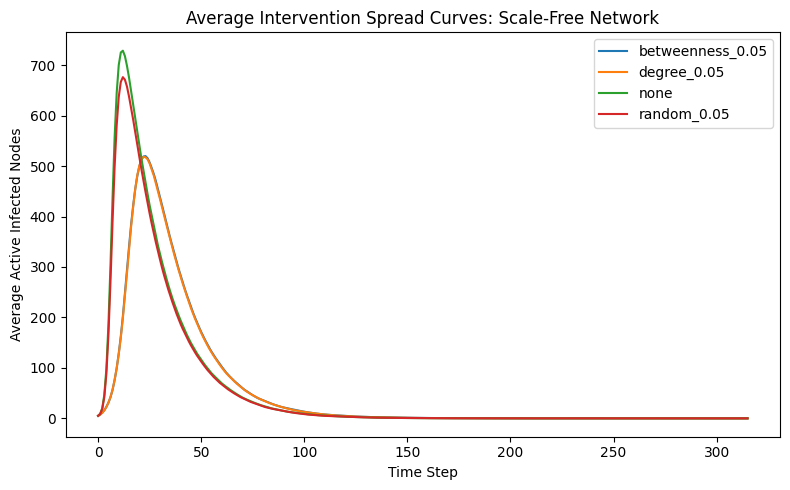

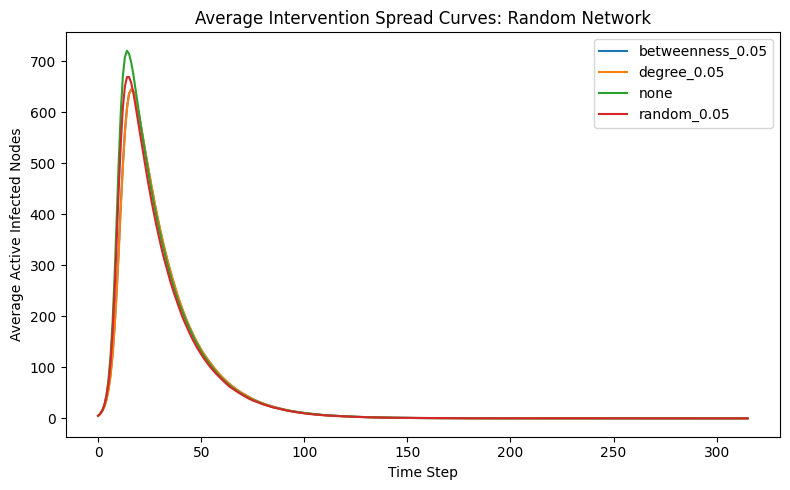

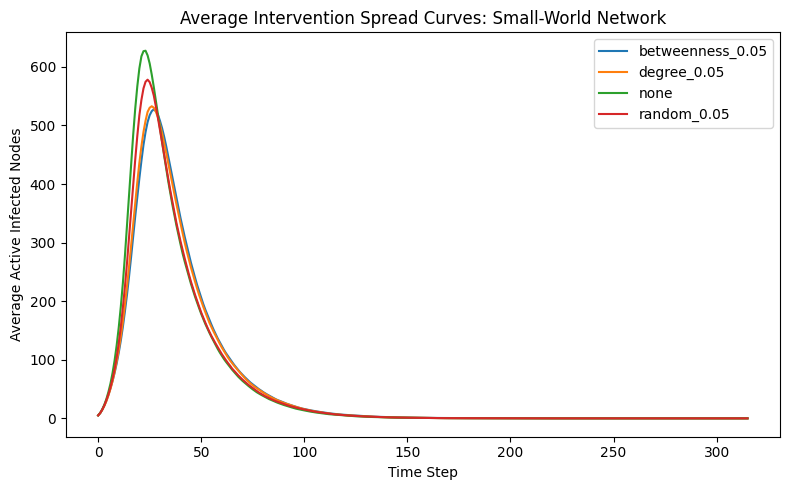

In [ ]:
if curve_df is not None:
    selected = curve_df[
        (
            (curve_df["strategy"] == "none") |
            ((curve_df["strategy"] == "degree") & (curve_df["fraction"] == 0.05)) |
            ((curve_df["strategy"] == "betweenness") & (curve_df["fraction"] == 0.05)) |
            ((curve_df["strategy"] == "random") & (curve_df["fraction"] == 0.05))
        )
    ].copy()
    
    selected["condition"] = selected.apply(
        lambda row: "none" if row["strategy"] == "none" else f"{row['strategy']}_{row['fraction']}",
        axis=1
    )
    
    for topology, title in {
        "BA": "Scale-Free Network",
        "ER": "Random Network",
        "WS": "Small-World Network"
    }.items():
        subset = selected[selected["topology"] == topology]
        avg_curve = subset.groupby(["condition", "time"])["infected"].mean().reset_index()
        
        plt.figure(figsize=(8, 5))
        for condition in avg_curve["condition"].unique():
            condition_data = avg_curve[avg_curve["condition"] == condition]
            plt.plot(condition_data["time"], condition_data["infected"], label=condition)
        
        plt.xlabel("Time Step")
        plt.ylabel("Average Active Infected Nodes")
        plt.title(f"Average Intervention Spread Curves: {title}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"{topology}_intervention_average_curves.png", dpi=300)
        plt.show()

## Matched strategy comparisons and whole-design inference

The experiment runner resets the random seed to the trial index before generating each graph. Consequently, within a topology, trial \(i\) regenerates the same graph across strategy and coverage conditions. Strategy comparisons are therefore matched by topology and trial rather than independent. The analyses below use repeated-measures and paired tests for the 5% comparisons, a Gaussian generalized estimating equation (GEE) for cumulative exposure across the complete intervention design, and trial-stratified log-rank tests for time to 50% infection. Trials that never reach 50% are retained as right-censored observations.

,Topology,F,Raw p,eta_squared,Levene p,Welch ANOVA p,Kruskal-Wallis p,Holm p
0,BA,82.8746,0.0000,0.3582,0.0030,0.0000,0.0000,0.0
1,ER,0.0005,0.9995,0.0000,0.0981,0.9995,0.9411,1.0
2,WS,0.4773,0.6209,0.0032,0.7194,0.6195,0.6855,1.0


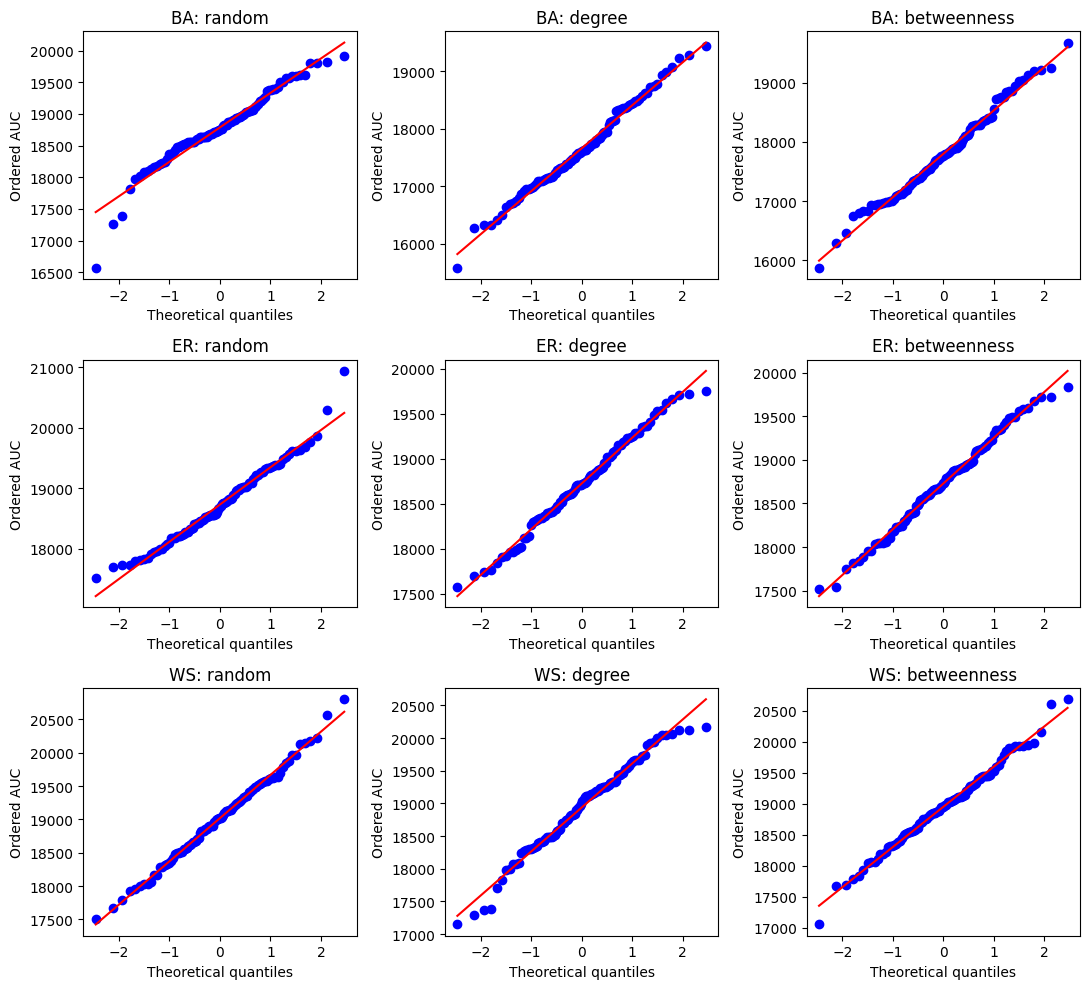

Saved: c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\figures\intervention_auc_qq_diagnostics.png


In [22]:
from scipy.stats import f_oneway, levene, kruskal, ttest_rel, probplot
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.oneway import anova_oneway
import statsmodels.formula.api as smf
from statsmodels.duration.survfunc import survdiff

strategy_order = ["random", "degree", "betweenness"]

# Omnibus diagnostics for cumulative exposure at 5% coverage.
diagnostic_rows = []
for topology in ["BA", "ER", "WS"]:
    subset = results[
        (results["topology"] == topology)
        & (results["fraction"] == 0.05)
        & (results["strategy"].isin(strategy_order))
    ]

    groups = [
        subset.loc[subset["strategy"] == strategy, "auc"].dropna()
        for strategy in strategy_order
    ]

    f_stat, p_value = f_oneway(*groups)
    df_between = len(groups) - 1
    df_within = sum(len(group) for group in groups) - len(groups)
    eta_squared = (
        (f_stat * df_between)
        / ((f_stat * df_between) + df_within)
    )

    diagnostic_rows.append({
        "Topology": topology,
        "F": f_stat,
        "Raw p": p_value,
        "eta_squared": eta_squared,
        "Levene p": levene(*groups, center="median").pvalue,
        "Welch ANOVA p": anova_oneway(groups, use_var="unequal").pvalue,
        "Kruskal-Wallis p": kruskal(*groups).pvalue,
    })

intervention_diagnostics = pd.DataFrame(diagnostic_rows)
intervention_diagnostics["Holm p"] = multipletests(
    intervention_diagnostics["Raw p"],
    method="holm",
)[1]

display(intervention_diagnostics.round(4))

# Q-Q plots for 5% cumulative exposure, saved as Supporting Online Material.
fig, axes = plt.subplots(3, 3, figsize=(11, 10))
for row, topology in enumerate(["BA", "ER", "WS"]):
    for col, strategy in enumerate(strategy_order):
        ax = axes[row, col]
        values = results.loc[
            (results["topology"] == topology)
            & (results["fraction"] == 0.05)
            & (results["strategy"] == strategy),
            "auc",
        ].dropna()

        probplot(values, dist="norm", plot=ax)
        ax.set_title(f"{topology}: {strategy}")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Ordered AUC")

fig.tight_layout()
qq_path = FIGURE_DIR / "intervention_auc_qq_diagnostics.png"
fig.savefig(qq_path, dpi=300, bbox_inches="tight")
plt.show()

intervention_diagnostics.to_csv(
    DATA_DIR / "intervention_statistical_diagnostics.csv",
    index=False,
)

print("Saved:", qq_path)

In [23]:
# Whole-design repeated-measures factorial model for cumulative exposure.
# A Gaussian generalized estimating equation (GEE) accounts for the
# repeated strategy and coverage conditions observed for each graph.
import statsmodels.api as sm
from statsmodels.genmod.cov_struct import Exchangeable

factorial_data = results[
    (results["strategy"].isin(strategy_order))
    & (results["fraction"].isin([0.01, 0.05, 0.10]))
].copy()

factorial_data["graph_id"] = (
    factorial_data["topology"].astype(str)
    + "_"
    + factorial_data["trial"].astype(str)
)

factorial_model = smf.gee(
    "auc ~ C(topology) * C(strategy) * C(fraction)",
    groups="graph_id",
    data=factorial_data,
    family=sm.families.Gaussian(),
    cov_struct=Exchangeable(),
)

factorial_fit = factorial_model.fit()
print(factorial_fit.summary())

# Omnibus Wald tests for all main effects and interactions.
factorial_wald = factorial_fit.wald_test_terms(
    skip_single=False,
).table

display(factorial_wald)
factorial_wald.to_csv(
    DATA_DIR / "auc_factorial_gee_wald_tests.csv",
)

                               GEE Regression Results                              
Dep. Variable:                         auc   No. Observations:                 2700
Model:                                 GEE   No. clusters:                      300
Method:                        Generalized   Min. cluster size:                   9
                      Estimating Equations   Max. cluster size:                   9
Family:                           Gaussian   Mean cluster size:                 9.0
Dependence structure:         Exchangeable   Num. iterations:                     2
Date:                     Mon, 22 Jun 2026   Scale:                      388609.906
Covariance type:                    robust   Time:                         16:01:49
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------

c:\Users\ishaa\OneDrive\Desktop\Projects\misinformation-topology-research\venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


,statistic,pvalue,df_constraint
Intercept,[[92851.19497344978]],0.0,1
C(topology),[[18.830727833172425]],8.146281360838355e-05,2
C(strategy),[[19.740912986392015]],5.167913205687825e-05,2
C(fraction),[[2760.1259956358967]],0.0,2
C(topology):C(strategy),[[12.40869331731667]],0.014557308454446832,4
C(topology):C(fraction),[[511.0178775447955]],2.773194422783839e-109,4
C(strategy):C(fraction),[[813.418629859971]],9.522246530387509e-175,4
C(topology):C(strategy):C(fraction),[[489.18455413408003]],1.4704094319535459e-100,8


In [ ]:
# Right-censored time-to-50% analysis.
# Trials that did not reach 50% are censored at their observed duration.
survival_rows = []

for topology in ["BA", "ER", "WS"]:
    for fraction in [0.01, 0.05, 0.10]:
        random_group = results[
            (results["topology"] == topology)
            & (results["strategy"] == "random")
            & (results["fraction"] == fraction)
        ][["trial", "t50", "duration"]].copy()

        for targeted_strategy in ["degree", "betweenness"]:
            targeted_group = results[
                (results["topology"] == topology)
                & (results["strategy"] == targeted_strategy)
                & (results["fraction"] == fraction)
            ][["trial", "t50", "duration"]].copy()

            random_group["group"] = "random"
            targeted_group["group"] = targeted_strategy

            survival_data = pd.concat(
                [random_group, targeted_group],
                ignore_index=True,
            )

            survival_data["event"] = survival_data["t50"].notna().astype(int)
            survival_data["time"] = survival_data["t50"].fillna(
                survival_data["duration"]
            )

            chi_square, p_value = survdiff(
                survival_data["time"],
                survival_data["event"],
                survival_data["group"],
                strata=survival_data["trial"],
            )

            survival_rows.append({
                "Topology": topology,
                "Coverage": fraction,
                "Comparison": f"{targeted_strategy} vs random",
                "Log-rank chi-square": chi_square,
                "Raw p": p_value,
            })

survival_results = pd.DataFrame(survival_rows)
survival_results["Holm p"] = multipletests(
    survival_results["Raw p"],
    method="holm",
)[1]

display(survival_results.round(4))
survival_results.to_csv(
    DATA_DIR / "t50_stratified_logrank_tests.csv",
    index=False,
)

The revised analyses support the same substantive conclusions while matching the experimental design. At 5% coverage, strategy had a large effect in BA networks, \(F(2,198)=184.44\), partial \(\eta^2=0.651\), but not in ER or WS networks. Paired degree-versus-random and betweenness-versus-random tests were both significant in BA networks after Holm correction, with \(d_z=-1.56\) and \(d_z=-1.44\), respectively. The whole-design GEE found a topology × strategy × coverage interaction, Wald \(\chi^2(8)=489.18\), \(p<0.001\). Trial-stratified log-rank tests showed that targeted placement delayed or prevented reaching 50% infection relative to random placement in every topology and coverage condition; all Holm-adjusted \(p\)-values were at most 0.0014.